# Bulk RNA-seq DESeq2 Analysis: Silica Exposure (RV)

**Tissue:** RV
**Data source:** Plasmidsaurus 3' tag-seq, Illumina platform

---

### What this notebook does

1. Loads raw counts matrix and sample metadata
2. Subsets to **RV** samples for the analysis
3. Builds a DESeq2 object
4. Runs QC: PCA, sample-distance heatmap, dispersion plot
6. Produces volcano plots

### Reusable code

This notebook depends on `pipeline_utils.R`, which lives in the same directory.


## 1. Setup

In [1]:
.libPaths()
R.version.string

[1] "/nfs/roberts/project/pi_epm38/jfd42/ycrc_conda/envs/20260429bulkrnaseq/lib/R/library"

[1] "R version 4.3.3 (2024-02-29)"

In [2]:
# Core packages
library("DESeq2")
library(tidyverse)
library(pheatmap)
library("RColorBrewer")
library(apeglm)
library(ashr)
library(openxlsx)
library(EnhancedVolcano)
library(ggrepel)

# Source pipeline_utils.R
source("~/project_pi_epm38/jfd42/pipelines/plasmidsaurus_bulkrnaseq/pipeline_utils.R")
source("~/project_pi_epm38/jfd42/pipelines/plasmidsaurus_bulkrnaseq/load_featurecounts.R")

# Default plot size
options(repr.plot.width = 10, repr.plot.height = 7)

set.seed(42)
Sys.time()

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loa

[1] "2026-09-09 17:22:45 EDT"

## 2. Configuration

In [7]:
# ----- File paths -----
COUNTS_MATRIX <- "/nfs/roberts/project/pi_epm38/jfd42/silica/RV_analysis/rawcounts_GRCm39_RV.txt"
GTF_PATH      <- "/nfs/roberts/project/pi_epm38/jfd42/GENCODE/GRCm39/gencode.vM39.primary_assembly.annotation.gtf"
METADATA_CSV <- "metadata_RV.csv"
OUTPUT_DIR    <- "results_rv_HbAdjusted"
PLOTS_DIR <- file.path(OUTPUT_DIR, "plots")

# ----- Sample selection -----
# Tissue Selection
TISSUE_FILTER <- "RV"

# Exposure selection
EXPOSURE_GROUPS <- c("CTRL", "Crystalline")

# Sexes to include
SEX_GROUPS <- c("F", "M")

# Optional: drop specific samples from analysis. Vvector of sample_id values that match the metadata sample_id column. e.g., c("1", "7")
DROP_SAMPLES <- character(0)  

# ----- Statistical design -----
# DESeq2 design formula.
DESIGN_FORMULA <- ~ Sex + pct_hb + Exposure

# Reference for each factor
EXPOSURE_REF <- "CTRL"
SEX_REF      <- "F"

# ----- Filtering -----
# A gene must have >= MIN_COUNT reads in >= SMALLEST_GROUP_SIZE samples to be retained.
MIN_COUNT           <- 10
SMALLEST_GROUP_SIZE <- 3

# ----- Significance thresholds -----
PADJ_THRESHOLD <- 0.05
LFC_THRESHOLD  <- 1.5

# ----- Make output directories -----
dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(PLOTS_DIR,  recursive = TRUE, showWarnings = FALSE)

cat("Configuration loaded.\n")
cat("  Tissue:    ", TISSUE_FILTER, "\n")
cat("  Exposures: ", paste(EXPOSURE_GROUPS, collapse = ", "), "\n")
cat("  Sexes:     ", paste(SEX_GROUPS, collapse = ", "), "\n")
cat("  Design:    ", deparse(DESIGN_FORMULA), "\n")
cat("  Output:    ", OUTPUT_DIR, "\n")

Configuration loaded.
  Tissue:     RV 
  Exposures:  CTRL, Crystalline 
  Sexes:      F, M 
  Design:     ~Sex + pct_hb + Exposure 
  Output:     results_rv_HbAdjusted 


## 3. Load expression data and metadata

In [8]:
# Load the counts matrix.
# This pulls only the _count columns, rounds fractional counts to integers
ps <- load_featurecounts(counts_path = COUNTS_MATRIX, gtf_path = GTF_PATH)

counts_full   <- ps$counts
gene_info     <- ps$gene_info
all_sample_ids <- ps$sample_ids

cat("\nFirst 5 sample IDs:\n")
print(head(all_sample_ids, 5))
cat("\nFirst 3 rows of gene_info:\n")
print(head(gene_info, 3))

Reading /nfs/roberts/project/pi_epm38/jfd42/silica/RV_analysis/rawcounts_GRCm39_RV.txt ...
Parsing gene_type from GTF for biotype annotation...
  Biotype assigned for 78045 of 78045 genes
  Genes:   78045 
  Samples: 15 
  Sample names: CTRL_F1, CTRL_F2, CTRL_F4, CTRL_M1, CTRL_M2, CTRL_M3, F1C1, F1C2, F2C2, FAmp_0, FAmp_LL, FAmp_RR, M1C1, M1C2, M1C3 
  Library size range:  21,461,823 to 27,785,875 reads

First 5 sample IDs:
[1] "CTRL_F1" "CTRL_F2" "CTRL_F4" "CTRL_M1" "CTRL_M2"

First 3 rows of gene_info:
        gene_id     gene_name   gene_biotype
1 4933401J01Rik 4933401J01Rik            TEC
2       Gm26206       Gm26206          snRNA
3          Xkr4          Xkr4 protein_coding


In [9]:
# Load metadata
metadata_full <- read.csv(METADATA_CSV, stringsAsFactors = FALSE)

# The sample_id column should match the column names in the counts matrix.

# Change sample_id from numeric to character
metadata_full$sample_id <- as.character(metadata_full$sample_id)

# Check that all metadata samples exist in counts
missing <- setdiff(metadata_full$sample_id, colnames(counts_full))
if (length(missing) > 0) {
  warning("Metadata samples missing from counts: ",
          paste(missing, collapse = ", "))
}

cat("Metadata loaded.\n")
cat("Total samples in metadata:", nrow(metadata_full), "\n\n")
table(metadata_full$Tissue, metadata_full$Exposure, metadata_full$Sex,
      dnn = c("Tissue", "Exposure", "Sex"))

Metadata loaded.
Total samples in metadata: 15 



, , Sex = F

      Exposure
Tissue Amorphous Crystalline CTRL
    RV         3           3    3

, , Sex = M

      Exposure
Tissue Amorphous Crystalline CTRL
    RV         0           3    3


## 4. Subset to RV samples in selected groups

In [10]:
# Filter metadata according to the config
metadata <- metadata_full %>%
  dplyr::filter(Tissue   == TISSUE_FILTER,
                Exposure %in% EXPOSURE_GROUPS,
                Sex      %in% SEX_GROUPS,
                !sample_id %in% DROP_SAMPLES)

# Convert factor columns and set reference levels
metadata$Exposure <- factor(metadata$Exposure, levels = c(EXPOSURE_REF,
                            setdiff(EXPOSURE_GROUPS, EXPOSURE_REF)))
metadata$Sex      <- factor(metadata$Sex, levels = c(SEX_REF,
                            setdiff(SEX_GROUPS, SEX_REF)))

# Use sample_id as rownames (must match colnames of counts)
rownames(metadata) <- metadata$sample_id

# Subset counts to match
counts <- counts_full[, metadata$sample_id]

cat("After filtering:\n")
cat("  Samples kept:", nrow(metadata), "\n\n")

# Show the design table
cat("Design composition:\n")
print(table(Sex = metadata$Sex, Exposure = metadata$Exposure))

# Sanity: every cell of the design has at least one sample, ideally >= 3
cell_counts <- as.matrix(table(metadata$Sex, metadata$Exposure))
if (any(cell_counts == 0)) {
  warning("Some Sex x Exposure cells have 0 samples - design will fail.")
} else if (any(cell_counts < 3)) {
  warning("Some Sex x Exposure cells have < 3 samples - low power expected.")
}

metadata

After filtering:
  Samples kept: 12 

Design composition:
   Exposure
Sex CTRL Crystalline
  F    3           3
  M    3           3


,sample_id,Sex,Exposure,Tissue,Mouse_ID,Notes
,<chr>,<fct>,<fct>,<chr>,<chr>,<chr>
CTRL_F1,CTRL_F1,F,CTRL,RV,FC1,
CTRL_F2,CTRL_F2,F,CTRL,RV,FC2,
CTRL_F4,CTRL_F4,F,CTRL,RV,FC4,VERIFY: filename FC4 vs decoding sheet 4FC - same mouse?
CTRL_M1,CTRL_M1,M,CTRL,RV,MC1,
CTRL_M2,CTRL_M2,M,CTRL,RV,MC2,
CTRL_M3,CTRL_M3,M,CTRL,RV,MC3,
F1C1,F1C1,F,Crystalline,RV,F1C1,
F1C2,F1C2,F,Crystalline,RV,F1C2,
F2C2,F2C2,F,Crystalline,RV,F2C2,


### Adding Hb% covariate prior to DESeq2

In [11]:
# Compute hemoglobin contamination % BEFORE building dds (needed as covariate)
hb_genes <- c("Hbb-bs", "Hbb-bt", "Hba-a1", "Hba-a2", "Hbb-y", "Hbb-bh1")
hb_ids   <- gene_info$gene_id[gene_info$gene_name %in% hb_genes]
hb_in_data <- intersect(hb_ids, rownames(counts))

pct_hb_per_sample <- 100 * colSums(counts[hb_in_data, , drop = FALSE]) /
                     pmax(colSums(counts), 1)

# Add to metadata as a covariate
metadata$pct_hb <- pct_hb_per_sample[metadata$sample_id]

cat("Per-sample %Hb (raw counts):\n")
print(round(metadata$pct_hb, 2))

# Sanity check: should not be NA anywhere
stopifnot(!any(is.na(metadata$pct_hb)))

Per-sample %Hb (raw counts):
 [1] 0.31 0.74 0.34 0.52 0.28 0.53 0.63 0.62 2.32 0.13 1.37 1.55


## 5. Fit DESeq2 model

In [12]:
dds <- build_dds(counts, metadata,
                 design = DESIGN_FORMULA,
                 min_count = MIN_COUNT,
                 smallest_group_size = SMALLEST_GROUP_SIZE)

Building DESeq2 object:
  Samples:         12 
  Initial genes:   78045 
  Design:          ~Sex + pct_hb + Exposure 
  Genes after filter (>= 10 in >= 3 samples): 21117 
Running DESeq() ...


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



Available result names:
[1] "Intercept"                    "Sex_M_vs_F"                  
[3] "pct_hb"                       "Exposure_Crystalline_vs_CTRL"


## 6. Quality control

### General QC and clustering

Check that:
- Size factors are reasonable (within ~2x of each other)
- Samples cluster by biology
- The dispersion estimates look like a normal "comet" shape

,Sample,SizeFactor,LibrarySize,Sex,Exposure
,<chr>,<dbl>,<dbl>,<fct>,<fct>
CTRL_F1,CTRL_F1,1.1534047,21410324,F,CTRL
CTRL_F2,CTRL_F2,1.3254494,25029000,F,CTRL
CTRL_F4,CTRL_F4,0.9621459,22459225,F,CTRL
CTRL_M1,CTRL_M1,1.1227263,23874121,M,CTRL
CTRL_M2,CTRL_M2,1.0865632,24760515,M,CTRL
CTRL_M3,CTRL_M3,0.8865166,21421361,M,CTRL
F1C1,F1C1,0.9146296,27479100,F,Crystalline
F1C2,F1C2,0.9192605,26281407,F,Crystalline
F2C2,F2C2,1.0485989,24861910,F,Crystalline


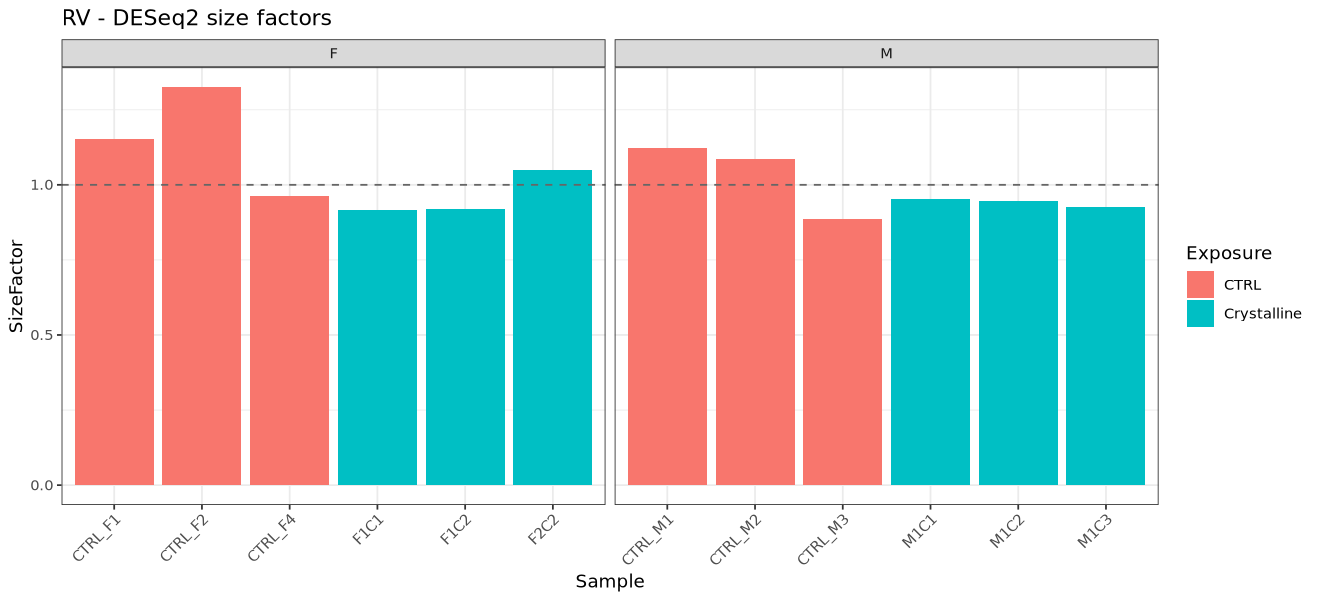

In [13]:
# Size factors per sample
sf_df <- data.frame(
  Sample      = colnames(dds),
  SizeFactor  = sizeFactors(dds),
  LibrarySize = colSums(counts(dds)),
  Sex         = colData(dds)$Sex,
  Exposure    = colData(dds)$Exposure
)

options(repr.plot.width = 11, repr.plot.height = 5)
ggplot(sf_df, aes(x = Sample, y = SizeFactor, fill = Exposure)) +
  geom_col() +
  geom_hline(yintercept = 1, linetype = "dashed", color = "grey40") +
  facet_wrap(~ Sex, scales = "free_x") +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = paste(TISSUE_FILTER, "- DESeq2 size factors"))

ggsave(file.path(PLOTS_DIR, "size_factors.pdf"), width = 11, height = 5)
sf_df

In [14]:
# rlog transformation for visualization
rld <- rlogTransformation(dds, blind = FALSE)
cat("rlog-transformed data ready:", dim(assay(rld)), "\n")

rlog-transformed data ready: 21117 12 


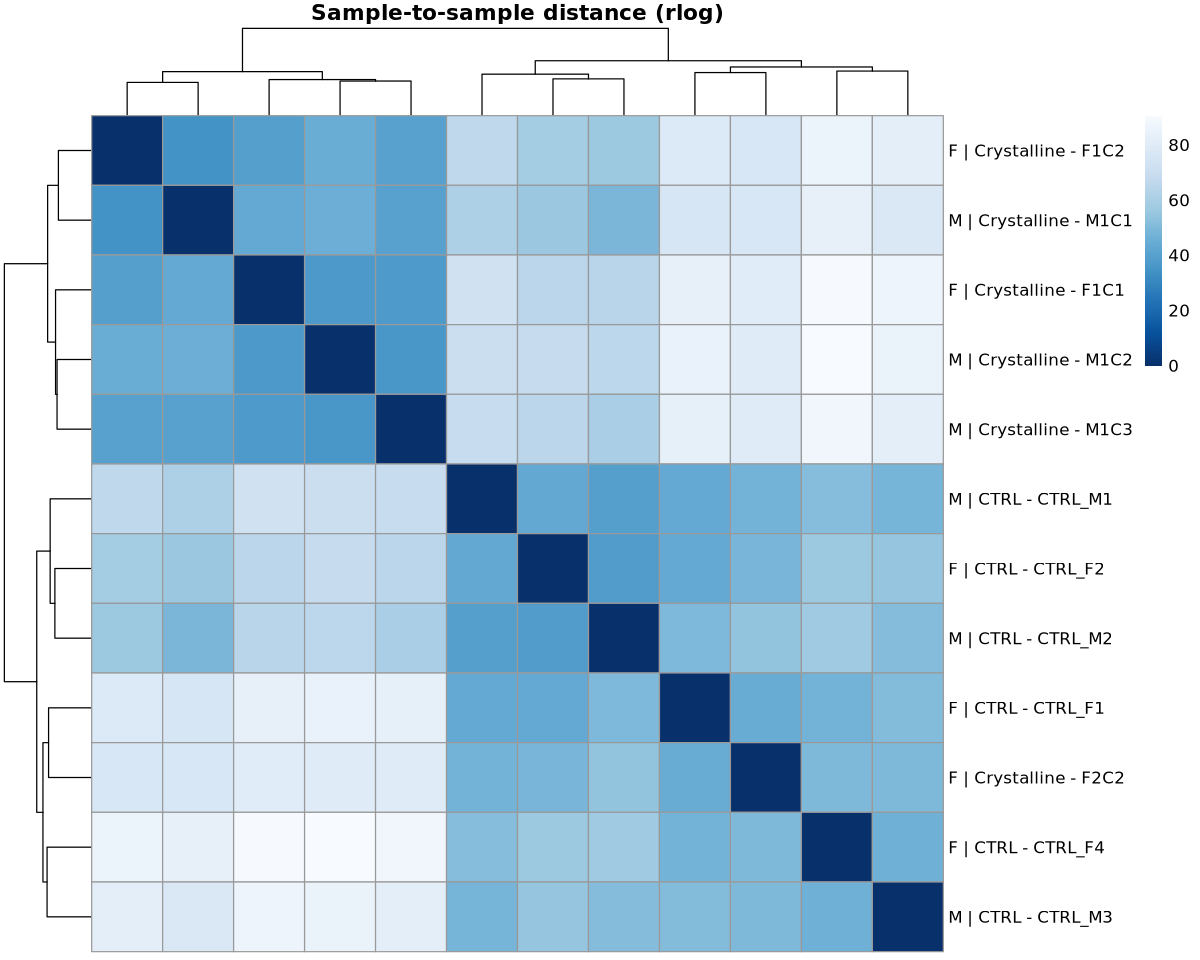

pdf 
  3

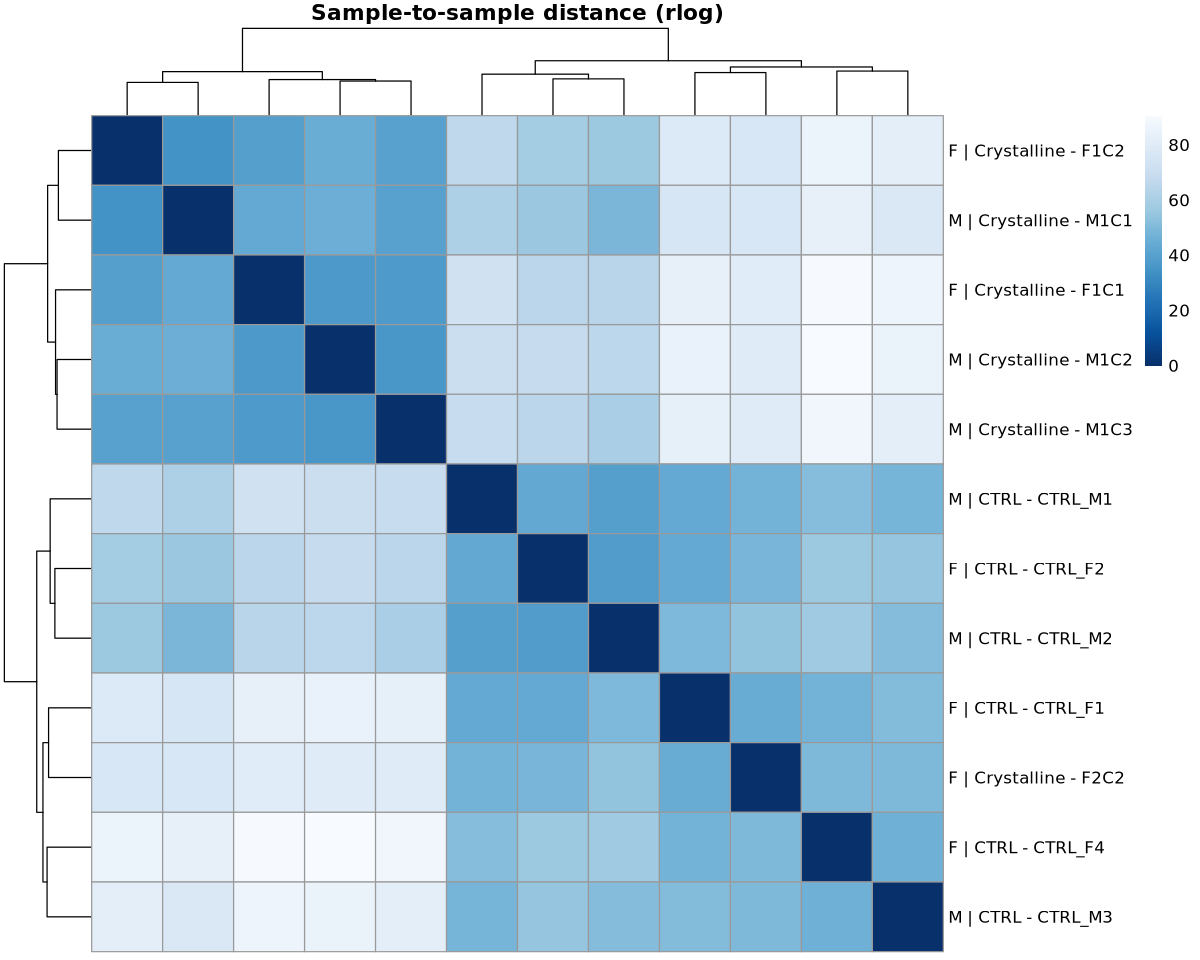

In [15]:
# Sample-distance heatmap
options(repr.plot.width = 10, repr.plot.height = 8)

# label by both Sex and Exposure for visibility
plot_sample_distance(rld, label_cols = c("Sex", "Exposure"))

pdf(file.path(PLOTS_DIR, "sample_distance_heatmap.pdf"), width = 10, height = 8)
plot_sample_distance(rld, label_cols = c("Sex", "Exposure"))
dev.off()

using ntop=5000 top features by variance



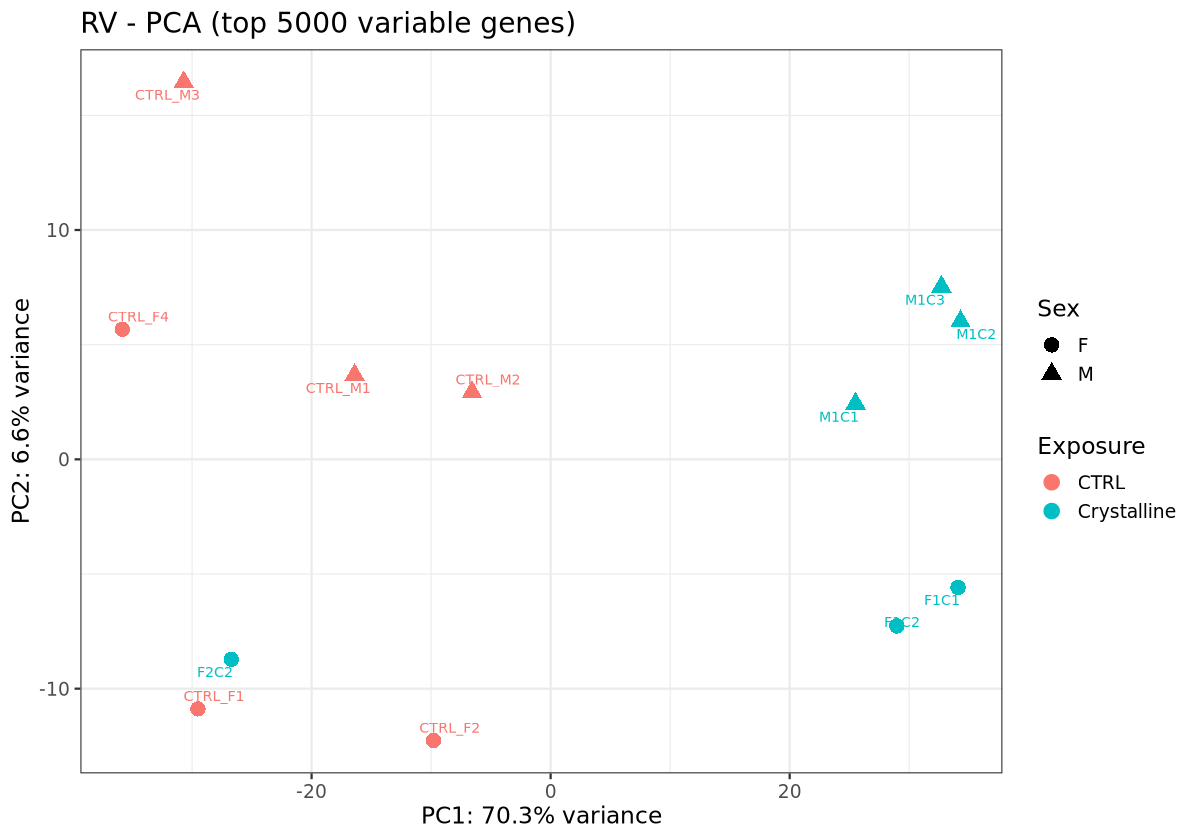

In [16]:
# PCA colored by Exposure, shaped by Sex
options(repr.plot.width = 10, repr.plot.height = 7)
p <- plot_pca_custom(rld, color_by = "Exposure", shape_by = "Sex",
                     ntop = 5000,
                     title = paste(TISSUE_FILTER,
                                   "- PCA (top 5000 variable genes)"))
print(p)
ggsave(file.path(PLOTS_DIR, "PCA_exposure_sex.pdf"), p,
       width = 10, height = 7)

agg_record_1501900930 
                    2

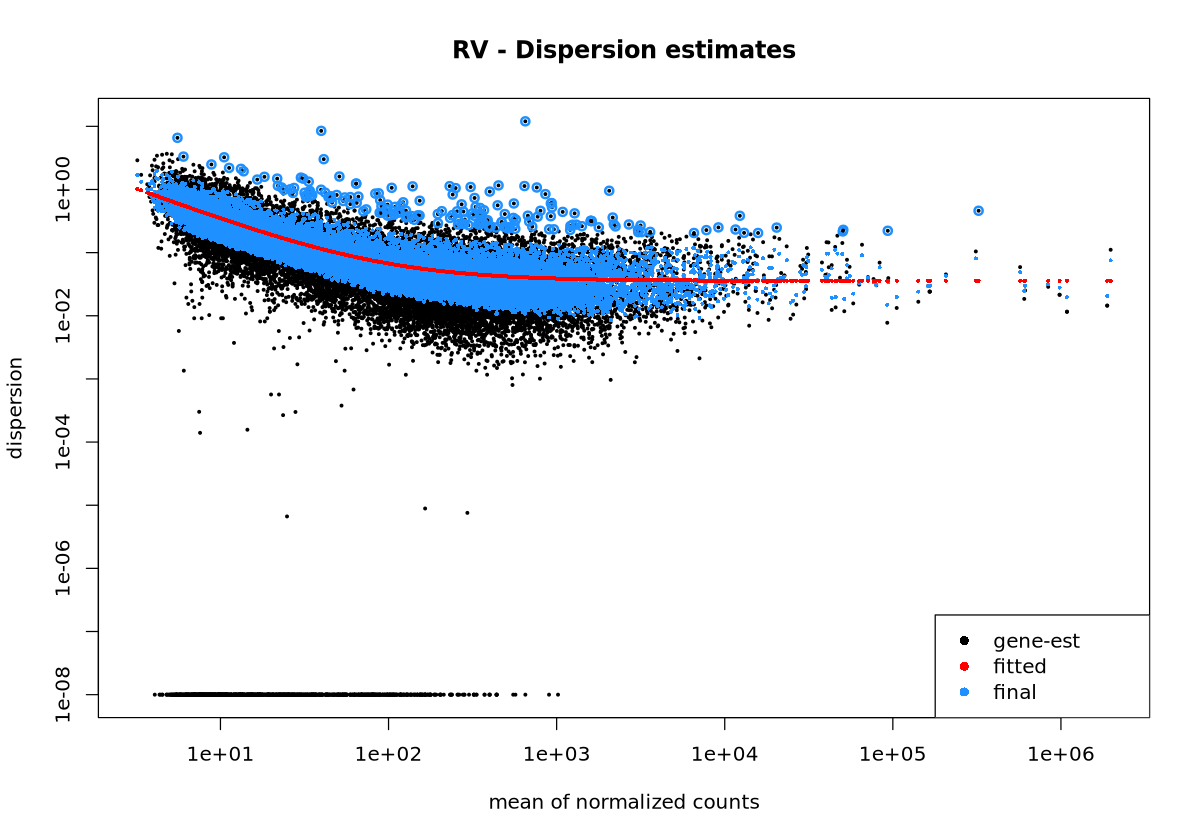

In [17]:
# Dispersion plot - should look like a comet with the red curve fitting nicely
options(repr.plot.width = 10, repr.plot.height = 7)
plotDispEsts(dds, main = paste(TISSUE_FILTER, "- Dispersion estimates"))

pdf(file.path(PLOTS_DIR, "dispersion_plot.pdf"), width = 10, height = 7)
plotDispEsts(dds, main = paste(TISSUE_FILTER, "- Dispersion estimates"))
dev.off()

In [18]:
# Compute full PCA on rlog-transformed data
pca <- prcomp(t(assay(rld)))

# Build a data frame with PC scores + metadata + %Hb
pc_check <- data.frame(
  PC1 = pca$x[, 1],
  PC2 = pca$x[, 2],
  PC3 = pca$x[, 3],
  Sample = colnames(rld),
  Sex = colData(rld)$Sex,
  Exposure = colData(rld)$Exposure,
  LibrarySize = colSums(counts(dds)),
  SizeFactor = sizeFactors(dds),
  pct_hb = metadata$pct_hb[match(colnames(rld), metadata$sample_id)]
)

cat("=== PC1 ===\n")
cat("Correlation with library size:  ", round(cor(pc_check$PC1, pc_check$LibrarySize), 3), "\n")
cat("Correlation with size factor:   ", round(cor(pc_check$PC1, pc_check$SizeFactor),  3), "\n")
cat("Correlation with %Hb:           ", round(cor(pc_check$PC1, pc_check$pct_hb),      3), "\n")
cat("ANOVA vs Exposure: p =", format.pval(summary(aov(PC1 ~ Exposure, data = pc_check))[[1]][["Pr(>F)"]][1]), "\n")
cat("ANOVA vs Sex:      p =", format.pval(summary(aov(PC1 ~ Sex,      data = pc_check))[[1]][["Pr(>F)"]][1]), "\n\n")

cat("=== PC2 ===\n")
cat("Correlation with library size:  ", round(cor(pc_check$PC2, pc_check$LibrarySize), 3), "\n")
cat("Correlation with %Hb:           ", round(cor(pc_check$PC2, pc_check$pct_hb),      3), "\n")
cat("ANOVA vs Exposure: p =", format.pval(summary(aov(PC2 ~ Exposure, data = pc_check))[[1]][["Pr(>F)"]][1]), "\n")
cat("ANOVA vs Sex:      p =", format.pval(summary(aov(PC2 ~ Sex,      data = pc_check))[[1]][["Pr(>F)"]][1]), "\n\n")

cat("=== PC3 ===\n")
cat("Correlation with %Hb:           ", round(cor(pc_check$PC3, pc_check$pct_hb),      3), "\n")
cat("ANOVA vs Exposure: p =", format.pval(summary(aov(PC3 ~ Exposure, data = pc_check))[[1]][["Pr(>F)"]][1]), "\n\n")

# Variance explained per PC
var_exp <- round(100 * summary(pca)$importance["Proportion of Variance", 1:5], 1)
cat("=== Variance explained ===\n")
print(var_exp)

=== PC1 ===
Correlation with library size:   0.898 
Correlation with size factor:    -0.428 
Correlation with %Hb:            0.115 
ANOVA vs Exposure: p = 0.0025913 
ANOVA vs Sex:      p = 0.46186 

=== PC2 ===
Correlation with library size:   -0.057 
Correlation with %Hb:            0.574 
ANOVA vs Exposure: p = 0.33003 
ANOVA vs Sex:      p = 0.99087 

=== PC3 ===
Correlation with %Hb:            0.465 
ANOVA vs Exposure: p = 0.40305 

=== Variance explained ===
 PC1  PC2  PC3  PC4  PC5 
57.5  8.6  7.4  5.3  4.4 



##### Ran the same PC analysis as before without removeBatchEffect() for %Hb to reduce risk of double adjustment. Look at the top hit genes below to see if any changes occurred compared to non-adjustment.

## 7. Primary contrast: Crystalline vs CTRL (averaged across sexes)

In [19]:
# Identify the relevant coefficient name
res_names <- resultsNames(dds)
exposure_coef <- grep("^Exposure_.*_vs_", res_names, value = TRUE)[1]
cat("Using coefficient:", exposure_coef, "\n")

res_exp <- extract_contrast(dds, gene_info, coef = exposure_coef)
head(res_exp, 10)

Using coefficient: Exposure_Crystalline_vs_CTRL 
Using coef-based shrinkage (apeglm) for: Exposure_Crystalline_vs_CTRL 


using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



,gene_id,gene_name,gene_biotype,mean_Crystalline,mean_CTRL,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2900092N22Rik,2900092N22Rik,TEC,25.76899,114.2194,69.99420,-3.361098,0.4014263,2.203259e-18,4.652621e-14
2,Lgals4,Lgals4,protein_coding,125.66506,547.5494,336.60725,-2.537116,0.3386537,8.283775e-15,3.750027e-11
3,Meg3,Meg3,lncRNA,153.83474,440.7126,297.27369,-1.946332,0.2644989,6.704529e-15,3.750027e-11
4,Erdr1y,Erdr1y,lncRNA,288.01715,721.8171,504.91713,-2.203247,0.2989190,7.205952e-15,3.750027e-11
5,ENSMUSG00000095041,ENSMUSG00000095041,protein_coding,168.24124,512.9654,340.60331,-1.992987,0.2774168,8.879167e-15,3.750027e-11
6,Gm50253,Gm50253,protein_coding,83.97929,241.7505,162.86489,-1.878247,0.2566308,1.066546e-14,3.753708e-11
7,Neat1,Neat1,lncRNA,2059.70124,8762.4426,5411.07190,-2.339551,0.3319296,3.018346e-14,9.105489e-11
8,Ccm2l,Ccm2l,protein_coding,76.83685,192.8402,134.83855,-1.798478,0.2482859,4.443382e-14,1.172886e-10
9,Gm42899,Gm42899,TEC,42.65265,131.1696,86.91113,-2.074685,0.2866239,9.578627e-14,2.247465e-10


In [20]:
summarize_significance(res_exp,
                       padj_thresh = PADJ_THRESHOLD,
                       lfc_thresh  = LFC_THRESHOLD)

=== Significance summary ===
Genes tested (non-NA padj): 21117 

padj < 0.05 :
  total:     8634 

padj < 0.05 AND |LFC| >= 1.5 ( 2.83 -fold):
  total:     1100 
  upregulated:   289 
  downregulated: 811 

padj < 0.05 AND |LFC| >= 0.585 (1.5-fold, more lenient):
  total:     6640 


Note: these LABEL_GENES were not found in the results (check spelling / filtering):
   Erdr1, Ccm21 
Labelling 22 of 21117 genes.


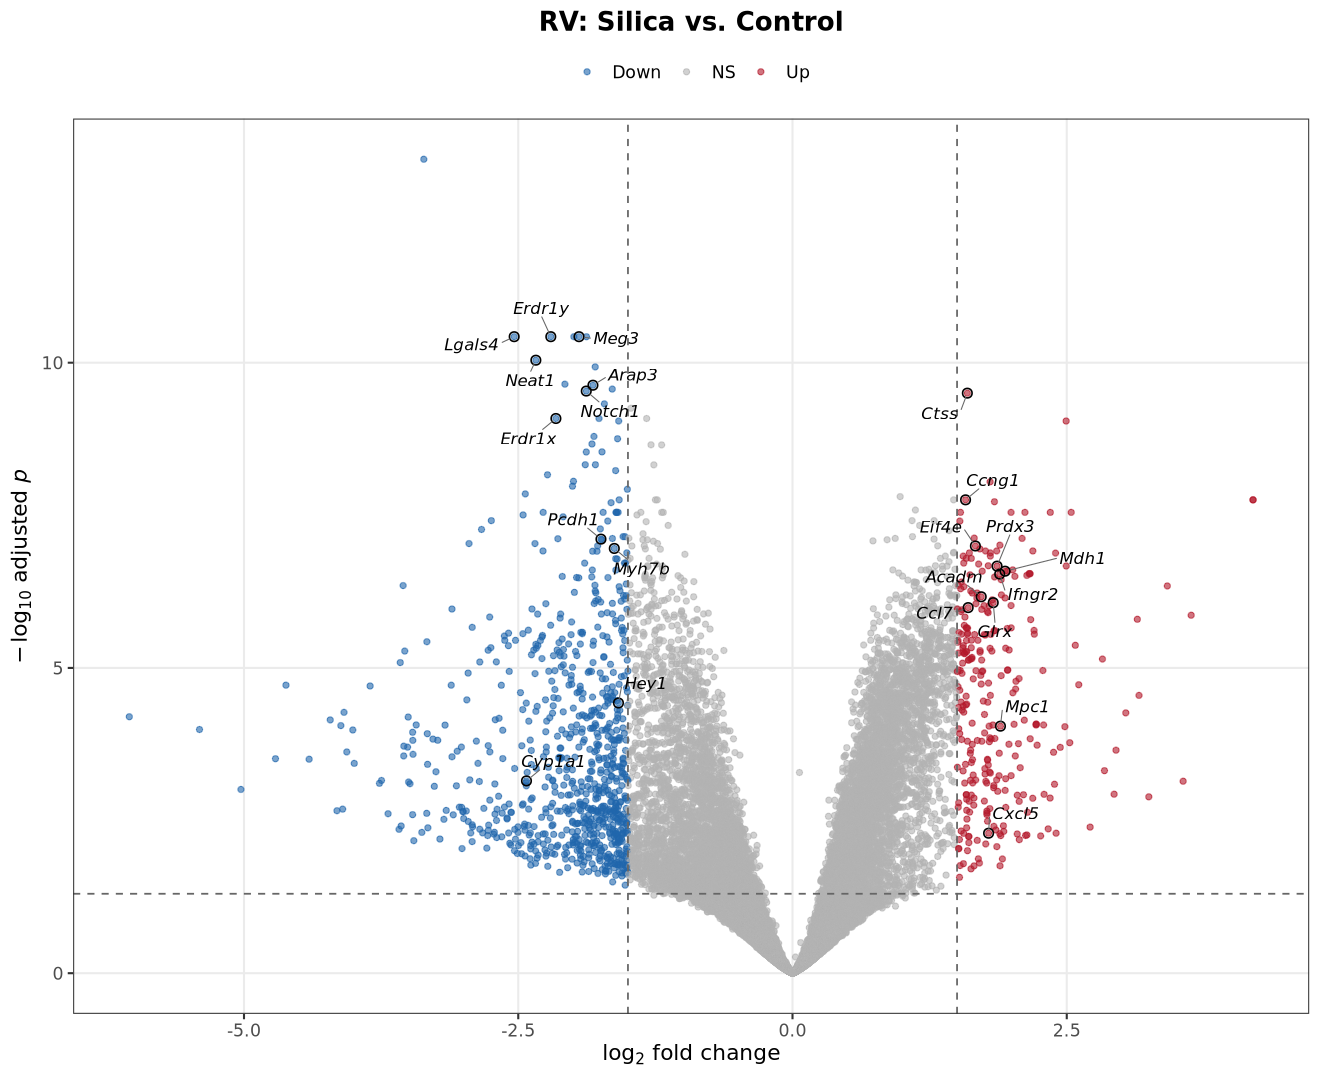

In [21]:
# === Volcano plot with a MANUAL label list ==================================
# Label ONLY the gene symbols in LABEL_GENES, at their existing volcano positions

suppressPackageStartupMessages({
  library(ggplot2)
  library(ggrepel)
  library(dplyr)
})

# Gene list to be labelled on plot
LABEL_GENES <- c(
  "Prdx3", "Mdh1", "Acadm", "Glrx", "Eif4e", "Ccng1", "Mpc1", "Erdr1",
  "Notch1", "Hey1", "Arap3", "Pcdh1", "Neat1", "Ccm21", "Lgals4", "Erdr1y",
  "Cyp1a1", "Ccl7", "Cxcl5", "Ctss", "Ifngr2", "Myh7b", "Meg3", "Erdr1x"
)

# ---- Build the plotting data frame from the DESeq2 result -----------------------
res_df <- as.data.frame(res_exp)
if (!"gene_name" %in% colnames(res_df)) {
  res_df$gene_name <- rownames(res_df)
}
res_df <- res_df %>% filter(!is.na(padj), !is.na(log2FoldChange))

res_df <- res_df %>%
  mutate(
    sig = case_when(
      padj < PADJ_THRESHOLD & log2FoldChange >=  LFC_THRESHOLD ~ "Up",
      padj < PADJ_THRESHOLD & log2FoldChange <= -LFC_THRESHOLD ~ "Down",
      TRUE ~ "NS"
    ),
    neglog10padj = -log10(padj)
  )

label_set <- tolower(LABEL_GENES)
res_df$to_label <- tolower(res_df$gene_name) %in% label_set

found <- tolower(res_df$gene_name[res_df$to_label])
missing <- LABEL_GENES[!tolower(LABEL_GENES) %in% found]
if (length(missing) > 0) {
  cat("Note: these LABEL_GENES were not found in the results (check spelling / filtering):\n  ",
      paste(missing, collapse = ", "), "\n")
}
cat("Labelling", sum(res_df$to_label), "of", nrow(res_df), "genes.\n")

# ---- Plot -------------------------------------------------------------------
sig_colors <- c(Up = "#B2182B", Down = "#2166AC", NS = "grey70")

volc <- ggplot(res_df, aes(x = log2FoldChange, y = neglog10padj)) +
  geom_point(aes(color = sig), size = 1.4, alpha = 0.6) +
  scale_color_manual(values = sig_colors, name = NULL) +
  geom_vline(xintercept = c(-LFC_THRESHOLD, LFC_THRESHOLD),
             linetype = "dashed", color = "grey40") +
  geom_hline(yintercept = -log10(PADJ_THRESHOLD),
             linetype = "dashed", color = "grey40") +
  geom_point(data = subset(res_df, to_label),
             color = "black", size = 2.2, shape = 21, fill = NA, stroke = 0.7) +
  geom_text_repel(
    data = subset(res_df, to_label),
    aes(label = gene_name),
    size = 3.5,
    fontface = "italic",
    max.overlaps = Inf,
    box.padding = 0.5,
    point.padding = 0.3,
    min.segment.length = 0,
    segment.color = "grey40",
    segment.size = 0.3
  ) +
  labs(x = expression(log[2]~fold~change),
       y = expression(-log[10]~adjusted~italic(p)),
       title = "RV: Silica vs. Control") +
  theme_bw(base_size = 13) +
  theme(panel.grid.minor = element_blank(),
        plot.title = element_text(face = "bold", hjust = 0.5),
        legend.position = "top")

options(repr.plot.width = 11, repr.plot.height = 9)
print(volc)

ggsave(file.path(PLOTS_DIR, paste0("volcano_", exposure_coef, "_labeled.pdf")),
       volc, width = 11, height = 9)


In [23]:
# Save outputs (full results, significant only, ranked for GSEA)
write_outputs_for_enrichment(res_exp, OUTPUT_DIR,
                             prefix = paste0(TISSUE_FILTER, "_", exposure_coef),
                             padj_thresh = PADJ_THRESHOLD,
                             lfc_thresh  = LFC_THRESHOLD)

Wrote results_rv_HbAdjusted/RV_Exposure_Crystalline_vs_CTRL_full_results.xlsx ( 21117 genes)
Saved enrichment-ready outputs to results_rv_HbAdjusted with prefix RV_Exposure_Crystalline_vs_CTRL 


## 8. Baseline sex effect (M vs F)

Useful as a sanity check (do you see expected sex-linked genes like Xist, Ddx3y,
Uty?).

In [24]:
sex_coef <- grep("^Sex_.*_vs_", res_names, value = TRUE)[1]

if (length(SEX_GROUPS) >= 2 && !is.na(sex_coef)) {
  cat("Using coefficient:", sex_coef, "\n")
  res_sex <- extract_contrast(dds, gene_info, coef = sex_coef)
  head(res_sex, 10)
} else {
  cat("Only one sex in this analysis - skipping sex contrast.\n")
  res_sex <- NULL
}

Using coefficient: Sex_M_vs_F 
Using coef-based shrinkage (apeglm) for: Sex_M_vs_F 


using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



,gene_id,gene_name,gene_biotype,mean_M,mean_F,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Tsix,Tsix,lncRNA,50.91897,3827.8782888,1939.39863,-6.210731,0.2587245,3.694732e-131,7.802165e-127
2,Eif2s3y,Eif2s3y,protein_coding,474.60389,4.3399473,239.47192,6.734902,0.3273018,1.278841e-94,1.350265e-90
3,Xist,Xist,lncRNA,40.23939,5341.0691325,2690.65426,-7.123172,0.4720613,6.149381e-56,4.328549e-52
4,Ddx3y,Ddx3y,protein_coding,1370.51103,3.2515220,686.88128,8.734520,0.5859709,1.460668e-53,7.711232e-50
5,Uty,Uty,protein_coding,316.30477,1.2926605,158.79871,7.893780,0.5380986,2.819944e-48,1.190975e-44
6,Kdm5d,Kdm5d,protein_coding,134.47735,0.3267229,67.40203,8.472497,0.9826463,3.074941e-23,1.082225e-19
7,Hsd11b1,Hsd11b1,protein_coding,311.86606,78.6670387,195.26655,1.828316,0.2219967,9.041743e-18,2.727636e-14
8,Gm55585,Gm55585,misc_RNA,0.00000,25.5636556,12.78183,-8.798169,2.8148271,3.588981e-13,9.473565e-10
9,Ccn1,Ccn1,protein_coding,807.60646,261.9601081,534.78328,1.558526,0.2357679,8.190720e-13,1.921816e-09


In [25]:
if (!is.null(res_sex)) {
  summarize_significance(res_sex,
                         padj_thresh = PADJ_THRESHOLD,
                         lfc_thresh  = LFC_THRESHOLD)

  # Are the usual sex-linked genes showing up?
  cat("\nClassic sex-linked genes (sanity check):\n")
  sex_markers <- c("Xist", "Ddx3y", "Uty", "Eif2s3y", "Kdm5d", "Tsix")
  print(res_sex %>%
        dplyr::filter(gene_name %in% sex_markers) %>%
        dplyr::select(gene_name, log2FoldChange, padj))
}

=== Significance summary ===
Genes tested (non-NA padj): 21117 

padj < 0.05 :
  total:     77 

padj < 0.05 AND |LFC| >= 1.5 ( 2.83 -fold):
  total:     39 
  upregulated:   35 
  downregulated: 4 

padj < 0.05 AND |LFC| >= 0.585 (1.5-fold, more lenient):
  total:     71 

Classic sex-linked genes (sanity check):
  gene_name log2FoldChange          padj
1      Tsix      -6.210731 7.802165e-127
2   Eif2s3y       6.734902  1.350265e-90
3      Xist      -7.123172  4.328549e-52
4     Ddx3y       8.734520  7.711232e-50
5       Uty       7.893780  1.190975e-44
6     Kdm5d       8.472497  1.082225e-19


Warning message:
“ggrepel: 4 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


Wrote results_rv_HbAdjusted/RV_Sex_M_vs_F_full_results.xlsx ( 21117 genes)
Saved enrichment-ready outputs to results_rv_HbAdjusted with prefix RV_Sex_M_vs_F 


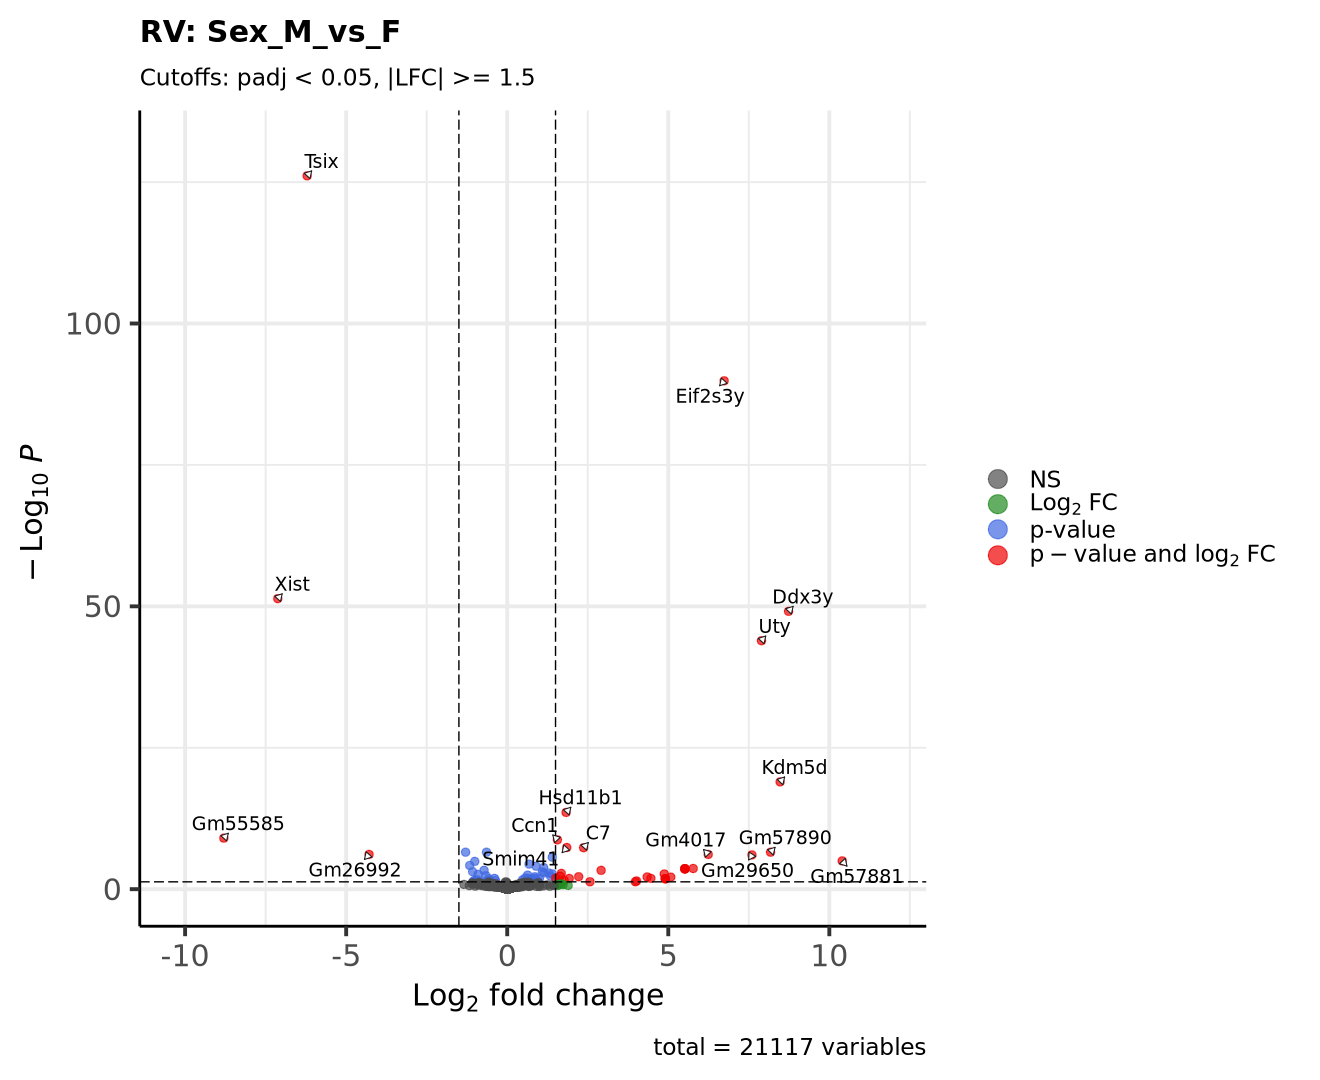

In [26]:
if (!is.null(res_sex)) {
  options(repr.plot.width = 11, repr.plot.height = 9)
  volc_sex <- plot_volcano_custom(res_sex,
                                   padj_thresh = PADJ_THRESHOLD,
                                   lfc_thresh  = LFC_THRESHOLD,
                                   title = paste0(TISSUE_FILTER, ": ", sex_coef))
  print(volc_sex)
  ggsave(file.path(PLOTS_DIR, paste0("volcano_", sex_coef, ".pdf")),
         volc_sex, width = 11, height = 9)

  write_outputs_for_enrichment(res_sex, OUTPUT_DIR,
                               prefix = paste0(TISSUE_FILTER, "_", sex_coef),
                               padj_thresh = PADJ_THRESHOLD,
                               lfc_thresh  = LFC_THRESHOLD)
}

## 9. Sex-specific exposure contrasts

Compare list of DEGs by sex

In [27]:
# Run the exposure contrast separately within each sex.
# Each subset is fit with ~ Exposure (only one sex present, so no Sex term).

N_TOP <- 50   # how many top DEGs to pull from each per-sex analysis

per_sex_deg <- list()   # will hold the full extract_contrast result per sex

for (this_sex in c("M", "F")) {

  cat("\n=== Exposure contrast, Sex =", this_sex, "===\n")

  # Subset metadata + counts to this sex
  md_sub     <- metadata %>% dplyr::filter(Sex == this_sex)
  counts_sub <- counts[, md_sub$sample_id]

  # Fit DESeq2 within this sex only
  dds_sub <- build_dds(counts_sub, md_sub,
                       design = ~ Exposure,
                       min_count = MIN_COUNT,
                       smallest_group_size = SMALLEST_GROUP_SIZE)

  # Pull the exposure coefficient (e.g. Exposure_Crystalline_vs_CTRL)
  coef_sub <- grep("^Exposure_.*_vs_", resultsNames(dds_sub), value = TRUE)[1]
  cat("Using coefficient:", coef_sub, "\n")

  res_sub <- extract_contrast(dds_sub, gene_info, coef = coef_sub)

  cat("--- Significance summary, Sex =", this_sex, "---\n")
  summarize_significance(res_sub, PADJ_THRESHOLD, LFC_THRESHOLD)

  per_sex_deg[[this_sex]] <- res_sub
}


=== Exposure contrast, Sex = M ===
Building DESeq2 object:
  Samples:         6 
  Initial genes:   78045 
  Design:          ~Exposure 
  Genes after filter (>= 10 in >= 3 samples): 18882 
Running DESeq() ...


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



Available result names:
[1] "Intercept"                    "Exposure_Crystalline_vs_CTRL"
Using coefficient: Exposure_Crystalline_vs_CTRL 
Using coef-based shrinkage (apeglm) for: Exposure_Crystalline_vs_CTRL 


using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



--- Significance summary, Sex = M ---
=== Significance summary ===
Genes tested (non-NA padj): 18881 

padj < 0.05 :
  total:     5484 

padj < 0.05 AND |LFC| >= 1.5 ( 2.83 -fold):
  total:     531 
  upregulated:   228 
  downregulated: 303 

padj < 0.05 AND |LFC| >= 0.585 (1.5-fold, more lenient):
  total:     4339 

=== Exposure contrast, Sex = F ===
Building DESeq2 object:
  Samples:         6 
  Initial genes:   78045 
  Design:          ~Exposure 
  Genes after filter (>= 10 in >= 3 samples): 19519 
Running DESeq() ...


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



Available result names:
[1] "Intercept"                    "Exposure_Crystalline_vs_CTRL"
Using coefficient: Exposure_Crystalline_vs_CTRL 
Using coef-based shrinkage (apeglm) for: Exposure_Crystalline_vs_CTRL 


using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



--- Significance summary, Sex = F ---
=== Significance summary ===
Genes tested (non-NA padj): 3625 

padj < 0.05 :
  total:     28 

padj < 0.05 AND |LFC| >= 1.5 ( 2.83 -fold):
  total:     3 
  upregulated:   2 
  downregulated: 1 

padj < 0.05 AND |LFC| >= 0.585 (1.5-fold, more lenient):
  total:     28 


In [28]:
# Pull the top N DEGs from each per-sex analysis.
# Note that they are ordered simply by p-adj.

top_deg <- lapply(per_sex_deg, function(res) {
  res %>%
    dplyr::filter(!is.na(padj)) %>%
    dplyr::arrange(padj) %>%
    dplyr::slice_head(n = N_TOP) %>%
    dplyr::select(gene_id, gene_name, gene_biotype,
                  log2FoldChange, padj)
})

top_M <- top_deg[["M"]]
top_F <- top_deg[["F"]]

cat("Top", N_TOP, "DEGs (MALES only):\n")
print(top_M)

cat("\nTop", N_TOP, "DEGs (FEMALES only):\n")
print(top_F)

Top 50 DEGs (MALES only):
         gene_id     gene_name                     gene_biotype log2FoldChange
1         Lgals4        Lgals4                   protein_coding      -2.676951
2        Mpc1-ps       Mpc1-ps             processed_pseudogene       2.596823
3        Apoo-ps       Apoo-ps             processed_pseudogene       2.687045
4          Neat1         Neat1                           lncRNA      -2.025918
5           Apoo          Apoo                   protein_coding       2.020597
6          Ccnl2         Ccnl2                   protein_coding      -1.522542
7          Sar1b         Sar1b                   protein_coding       2.059479
8         Gm6419        Gm6419             processed_pseudogene       2.458639
9        Gm68058       Gm68058                           lncRNA       2.634596
10       Gm10108       Gm10108 transcribed_processed_pseudogene       1.779579
11       Gm73848       Gm73848                           lncRNA       1.750979
12          Cycs          

In [29]:
# Rough overlap comparison

side_by_side <- data.frame(
  rank            = seq_len(N_TOP),
  M_gene          = top_M$gene_name,
  M_log2FC        = round(top_M$log2FoldChange, 2),
  M_padj          = signif(top_M$padj, 3),
  F_gene          = top_F$gene_name,
  F_log2FC        = round(top_F$log2FoldChange, 2),
  F_padj          = signif(top_F$padj, 3),
  stringsAsFactors = FALSE
)

cat("Top", N_TOP, "DEGs side by side (ranked by padj within each sex):\n")
print(side_by_side)

# Overlap between the two top-N lists (by gene_id, robust to symbol duplicates)
in_both  <- intersect(top_M$gene_id, top_F$gene_id)
M_only   <- setdiff(top_M$gene_id, top_F$gene_id)
F_only   <- setdiff(top_F$gene_id, top_M$gene_id)

lbl <- function(ids, tbl) {
  g <- tbl$gene_name[match(ids, tbl$gene_id)]
  g[is.na(g) | g == ""] <- ids[is.na(g) | g == ""]
  sort(g)
}

cat("\n=== Overlap of top", N_TOP, "DEG lists ===\n")
cat("In BOTH lists (", length(in_both), "):\n", sep = "")
print(lbl(in_both, top_M))
cat("\nMALES only (", length(M_only), "):\n", sep = "")
print(lbl(M_only, top_M))
cat("\nFEMALES only (", length(F_only), "):\n", sep = "")
print(lbl(F_only, top_F))

Top 50 DEGs side by side (ranked by padj within each sex):
   rank        M_gene M_log2FC   M_padj        F_gene F_log2FC  F_padj
1     1        Lgals4    -2.68 1.42e-21       Gm57050     0.98 0.00194
2     2       Mpc1-ps     2.60 1.42e-21          Gpx1     0.93 0.00194
3     3       Apoo-ps     2.69 2.83e-21          Lyz2     1.10 0.00194
4     4         Neat1    -2.03 2.74e-20         H2-Aa     1.29 0.00194
5     5          Apoo     2.02 9.72e-18         Mllt6    -0.96 0.00589
6     6         Ccnl2    -1.52 1.15e-17       Gm67237     1.20 0.00714
7     7         Sar1b     2.06 2.53e-17         Coro6    -1.04 0.00714
8     8        Gm6419     2.46 2.68e-17         Neat1    -1.84 0.01260
9     9       Gm68058     2.63 2.53e-16        Ube2l6     1.47 0.01640
10   10       Gm10108     1.78 2.57e-16        H2-Eb1     1.26 0.02650
11   11       Gm73848     1.75 3.85e-16          Speg    -0.81 0.03550
12   12          Cycs     1.63 4.76e-16        Hbb-bt     1.58 0.03550
13   13       Gm16

In [30]:
# Save the per-sex top-N lists and the side-by-side comparison for manual review.

write.csv(top_M,
          file.path(OUTPUT_DIR, paste0(TISSUE_FILTER, "_top", N_TOP, "_DEGs_males.csv")),
          row.names = FALSE)
write.csv(top_F,
          file.path(OUTPUT_DIR, paste0(TISSUE_FILTER, "_top", N_TOP, "_DEGs_females.csv")),
          row.names = FALSE)
write.csv(side_by_side,
          file.path(OUTPUT_DIR, paste0(TISSUE_FILTER, "_top", N_TOP, "_DEGs_M_vs_F_sidebyside.csv")),
          row.names = FALSE)

# Also drop them into a single multi-sheet workbook
wb <- createWorkbook()
addWorksheet(wb, "top_males");       writeData(wb, "top_males",       top_M)
addWorksheet(wb, "top_females");     writeData(wb, "top_females",     top_F)
addWorksheet(wb, "side_by_side");    writeData(wb, "side_by_side",    side_by_side)
saveWorkbook(wb,
             file.path(OUTPUT_DIR, paste0(TISSUE_FILTER, "_top", N_TOP, "_DEGs_by_sex.xlsx")),
             overwrite = TRUE)

cat("Saved per-sex top-", N_TOP, " DEG lists and side-by-side comparison to ",
    OUTPUT_DIR, "\n", sep = "")

Saved per-sex top-50 DEG lists and side-by-side comparison to results_rv_HbAdjusted


## Save normalized counts and DESeq2 objects

In [31]:
# Normalized counts (useful for plotting individual genes)
norm_counts <- counts(dds, normalized = TRUE) %>%
  as.data.frame() %>%
  tibble::rownames_to_column("gene_id") %>%
  dplyr::left_join(gene_info, by = "gene_id") %>%
  dplyr::relocate(gene_id, gene_name, gene_biotype)

write.csv(norm_counts,
          file.path(OUTPUT_DIR, "normalized_counts.csv"),
          row.names = FALSE)
write.xlsx(norm_counts,
           file.path(OUTPUT_DIR, "normalized_counts.xlsx"),
           asTable = TRUE,
           tableStyle = "TableStyleMedium2",
           firstRow = TRUE)

cat("Saved normalized counts (",
    nrow(norm_counts), "genes x", ncol(norm_counts), "cols)\n")

Saved normalized counts ( 21117 genes x 15 cols)


In [32]:
# Save DESeq2 objects so you can reload without re-running
saveRDS(dds, file.path(OUTPUT_DIR, "dds.rds"))
saveRDS(rld, file.path(OUTPUT_DIR, "rld.rds"))
cat("Saved DESeq2 objects.\n")
cat("Reload later with:\n")
cat("  dds <- readRDS('", file.path(OUTPUT_DIR, "dds.rds"), "')\n", sep = "")
cat("  rld <- readRDS('", file.path(OUTPUT_DIR, "rld.rds"), "')\n", sep = "")

Saved DESeq2 objects.
Reload later with:
  dds <- readRDS('results_rv_HbAdjusted/dds.rds')
  rld <- readRDS('results_rv_HbAdjusted/rld.rds')


## 13. Session info

In [28]:
sessionInfo()
capture.output(sessionInfo(), file = file.path(OUTPUT_DIR, "sessionInfo.txt"))
Sys.time()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.6 (Plow)

Matrix products: default
BLAS/LAPACK: /nfs/roberts/project/pi_epm38/jfd42/ycrc_conda/envs/20260429bulkrnaseq/lib/libopenblasp-r0.3.32.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] EnhancedVolcano_1.20.0      ggrepel_0.9.6              
 [3] openxlsx_4.2.8              ashr_2.2-63                
 [5] apeglm_1.24.0               RColorBrewer_1.1-3         
 [7] pheatmap_1.0.13          

[1] "2026-07-31 14:10:44 EDT"